### **Notebook 11: Análisis de correlación**

##### **Objetivo:** Este notebook tiene como objetivo realizar el análisis estadístico final de las variables seleccionadas y construir los datasets definitivos para las etapas posteriores de modelamiento predictivo.

##### **Procecimiento:** El proceso se divide en dos grandes etapas:

**Análisis de asociación entre variables, utilizando:**
- Correlación de Spearman para variables numéricas.
- V de Cramer para variables categóricas.

**Construcción de los datasets finales de entrenamiento y prueba, mediante:**
- Unificación de los datos correspondientes a los años 2019-2024.
- Selección de las variables utilizadas en el modelamiento.
- Transformación de variables categóricas mediante One-Hot Encoding.
- Separación de la cohorte oncológica y la cohorte control.
- Alineación de las columnas generadas mediante One-Hot Encoding entre los distintos años.
- División de cada cohorte en conjuntos de entrenamiento y prueba.
- Estratificación del split según la variable MORTALIDAD.
- Exportación de cuatro datasets definitivos.

Cargando y unificando datasets (2019-2024)...
Dataset unificado con 5.725.670 filas.

Calculando correlación de Spearman para variables numéricas...


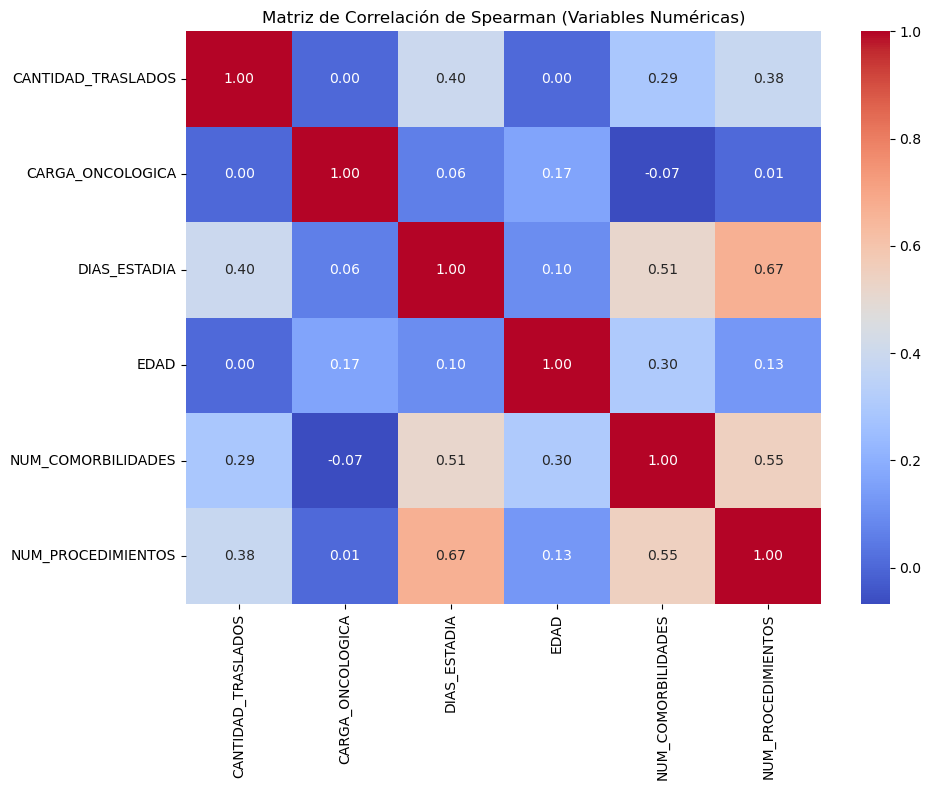


Calculando V de Cramer para variables categóricas (esto puede tardar unos minutos)...


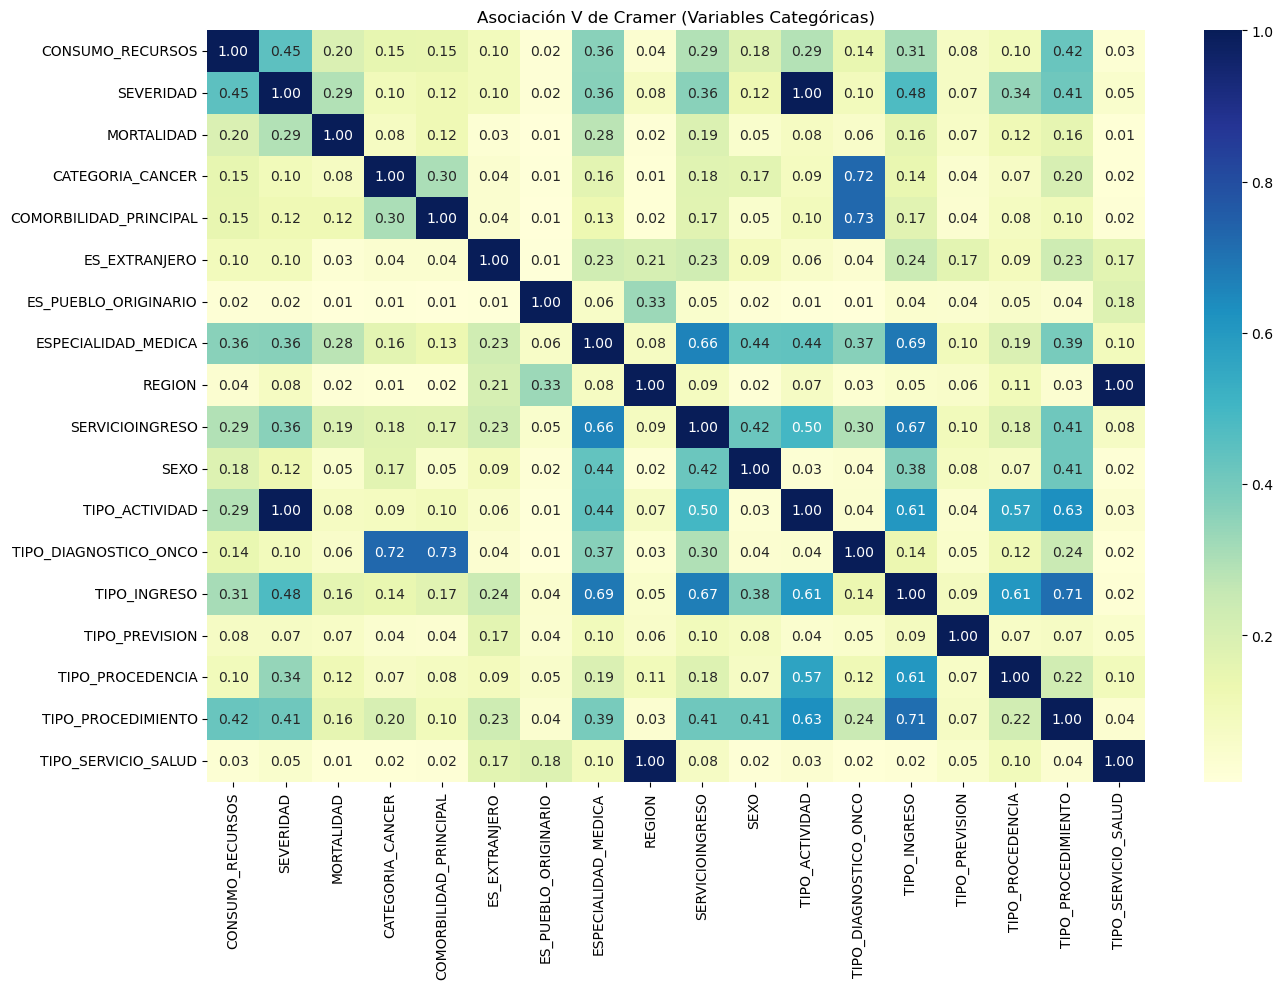


Análisis completado. Archivos guardados en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final


In [ ]:
import pandas as pd # Librería para manipulación de datos
import numpy as np # Librería para operaciones numéricas
import seaborn as sns # Librería para visualización de datos
import matplotlib.pyplot as plt # Librería para creación de gráficos
from scipy.stats import spearmanr, chi2_contingency # Librería para cálculos estadísticos
import os

# ============================================================================
# RESULTADOS GENERADOS:
# - Matriz de correlación de Spearman en formato CSV.
# - Heatmap de correlación de Spearman en formato PNG.
# - Matriz de asociación V de Cramer en formato CSV.
# - Heatmap de asociación V de Cramer en formato PNG.
# ============================================================================

# ============================================================================
# 1. CARGA Y UNIFICACIÓN DE LOS DATASETS
# ============================================================================

# Define la carpeta donde se encuentran los datasets procesados.
carpeta_procesados = "../../Datos/Datos procesados"

# Define la carpeta donde se almacenarán los resultados del análisis.
dir_salida = "../../Resultados/Resultados (etapa 1 y 2)/Análisis final"

# Crea la carpeta de resultados si todavía no existe.
os.makedirs(
    dir_salida,
    exist_ok=True
)

# Genera los nombres de los archivos correspondientes a los años 2019-2024.
archivos = [
    f"GRD_PROCESADO_{año}_DERIVADAS.csv"
    for año in range(2019, 2025)
]

# Informa que comienza la carga y unificación de los datasets.
print(
    "Cargando y unificando datasets (2019-2024)..."
)

# Inicializa una lista para almacenar temporalmente cada dataset.
df_list = []


# Recorre todos los archivos definidos anteriormente.
for f in archivos:

    # Comprueba si el archivo existe en la carpeta de procesamiento.
    if os.path.exists(
        f"{carpeta_procesados}/{f}"
    ):

        # Lee el dataset correspondiente al año.
        temp = pd.read_csv(
            f"{carpeta_procesados}/{f}",
            low_memory=False
        )

        # Extrae el año desde el nombre del archivo y lo almacena como variable.
        temp['AÑO_DATA'] = int(
            f.split('_')[2]
        )

        # Agrega el dataset anual a la lista de datasets.
        df_list.append(temp)


# Une todos los datasets anuales en un único DataFrame.
df = pd.concat(
    df_list,
    ignore_index=True
)

# Informa la cantidad total de registros del dataset unificado.
print(
    f"Dataset unificado con {len(df):,} filas."
    .replace(',', '.')
)


# ============================================================================
# 2. DEFINICIÓN DE VARIABLES
# ============================================================================

# Define las variables numéricas utilizadas para el análisis de Spearman.
vars_num = [
    'CANTIDAD_TRASLADOS',
    'CARGA_ONCOLOGICA',
    'DIAS_ESTADIA',
    'EDAD',
    'NUM_COMORBILIDADES',
    'NUM_PROCEDIMIENTOS'
]


# Define las variables categóricas utilizadas para el análisis de V de Cramer.
vars_cat = [
    'CONSUMO_RECURSOS',
    'SEVERIDAD',
    'MORTALIDAD',
    'CATEGORIA_CANCER',
    'COMORBILIDAD_PRINCIPAL',
    'ES_EXTRANJERO',
    'ES_PUEBLO_ORIGINARIO',
    'ESPECIALIDAD_MEDICA',
    'REGION',
    'SERVICIOINGRESO',
    'SEXO',
    'TIPO_ACTIVIDAD',
    'TIPO_DIAGNOSTICO_ONCO',
    'TIPO_INGRESO',
    'TIPO_PREVISION',
    'TIPO_PROCEDENCIA',
    'TIPO_PROCEDIMIENTO',
    'TIPO_SERVICIO_SALUD'
]


# ============================================================================
# 3. CORRELACIÓN NUMÉRICA: SPEARMAN
# ============================================================================

# Informa que comienza el cálculo de la correlación de Spearman.
print(
    "\nCalculando correlación de Spearman para variables numéricas..."
)

# Calcula la matriz de correlaciones de Spearman entre las variables numéricas.
corr_num = df[
    vars_num
].corr(
    method='spearman'
)


# ============================================================================
# 4. GUARDAR MATRIZ DE SPEARMAN
# ============================================================================

# Define la ruta del archivo CSV donde se guardará la matriz.
ruta_spearman_csv = (
    f"{dir_salida}/Matriz_Correlacion_Spearman.csv"
)

# Guarda la matriz de correlación en formato CSV.
corr_num.to_csv(
    ruta_spearman_csv,
    encoding='utf-8-sig'
)


# ============================================================================
# 5. VISUALIZACIÓN DE CORRELACIÓN DE SPEARMAN
# ============================================================================

# Define el tamaño de la figura.
plt.figure(
    figsize=(10, 8)
)

# Genera el mapa de calor de las correlaciones.
sns.heatmap(
    corr_num,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

# Define el título del gráfico.
plt.title(
    "Matriz de Correlación de Spearman (Variables Numéricas)"
)

# Ajusta automáticamente los elementos de la figura.
plt.tight_layout()

# Define la ruta donde se guardará el gráfico.
ruta_spearman_png = (
    f"{dir_salida}/Heatmap_Spearman.png"
)

# Guarda el gráfico en formato PNG con alta resolución.
plt.savefig(
    ruta_spearman_png,
    dpi=300
)

# Muestra el gráfico en pantalla.
plt.show()


# ============================================================================
# 6. ASOCIACIÓN CATEGÓRICA: V DE CRAMER
# ============================================================================

# Informa que comienza el cálculo de V de Cramer.
print(
    "\nCalculando V de Cramer para variables categóricas "
    "(esto puede tardar unos minutos)..."
)


# ============================================================================
# FUNCIÓN: CRAMERS_V
# ============================================================================

def cramers_v(x, y):
    """
    Definición:
        Calcula la intensidad de asociación entre dos variables categóricas
        utilizando el estadístico V de Cramer basado en una prueba Chi-cuadrado.

    Entrada:
        x: Primera variable categórica.
        y: Segunda variable categórica.

    Salida:
        Retorna un valor numérico entre 0 y 1 que representa la intensidad
        de la asociación entre las dos variables.
    """

    # Construye la tabla de contingencia entre las dos variables.
    confusion_matrix = pd.crosstab(
        x,
        y
    )

    # Calcula el estadístico Chi-cuadrado de la tabla de contingencia.
    chi2 = chi2_contingency(
        confusion_matrix
    )[0]

    # Calcula el número total de observaciones de la tabla.
    n = confusion_matrix.sum().sum()

    # Calcula el estadístico phi cuadrado.
    phi2 = chi2 / n

    # Obtiene el número de filas y columnas de la tabla de contingencia.
    r, k = confusion_matrix.shape

    # Aplica la corrección del estadístico phi para reducir el sesgo.
    phi2corr = max(
        0,
        phi2 - (
            ((k - 1) * (r - 1))
            / (n - 1)
        )
    )

    # Calcula el número de filas corregido.
    rcorr = (
        r
        - ((r - 1) ** 2)
        / (n - 1)
    )

    # Calcula el número de columnas corregido.
    kcorr = (
        k
        - ((k - 1) ** 2)
        / (n - 1)
    )

    # Calcula y retorna el V de Cramer corregido.
    return np.sqrt(
        phi2corr
        / min(
            (kcorr - 1),
            (rcorr - 1)
        )
    )


# ============================================================================
# 7. CÁLCULO DE LA MATRIZ DE V DE CRAMER
# ============================================================================

# Inicializa una lista para almacenar las filas de la matriz.
rows = []


# Recorre cada variable categórica como primera variable.
for var1 in vars_cat:

    # Inicializa la lista que almacenará las asociaciones de la fila actual.
    col = []

    # Recorre cada variable categórica como segunda variable.
    for var2 in vars_cat:

        # Calcula el V de Cramer entre ambas variables.
        col.append(
            cramers_v(
                df[var1],
                df[var2]
            )
        )

    # Agrega la fila completa a la matriz de resultados.
    rows.append(col)


# Construye la matriz de V de Cramer utilizando los nombres de las variables.
v_cramer_matrix = pd.DataFrame(
    rows,
    index=vars_cat,
    columns=vars_cat
)


# ============================================================================
# 8. GUARDAR MATRIZ DE V DE CRAMER
# ============================================================================

# Define la ruta del archivo CSV donde se guardará la matriz.
ruta_cramer_csv = (
    f"{dir_salida}/Matriz_Asociacion_Cramer.csv"
)

# Guarda la matriz de asociación en formato CSV.
v_cramer_matrix.to_csv(
    ruta_cramer_csv,
    encoding='utf-8-sig'
)


# ============================================================================
# 9. VISUALIZACIÓN DE V DE CRAMER
# ============================================================================

# Define el tamaño de la figura para la matriz de variables categóricas.
plt.figure(
    figsize=(14, 10)
)

# Genera el mapa de calor de las asociaciones categóricas.
sns.heatmap(
    v_cramer_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt=".2f"
)

# Define el título del gráfico.
plt.title(
    "Asociación V de Cramer (Variables Categóricas)"
)

# Ajusta automáticamente los elementos de la figura.
plt.tight_layout()

# Define la ruta donde se guardará el gráfico.
ruta_cramer_png = (
    f"{dir_salida}/Heatmap_Cramer.png"
)

# Guarda el gráfico en formato PNG con alta resolución.
plt.savefig(
    ruta_cramer_png,
    dpi=300
)

# Muestra el gráfico en pantalla.
plt.show()


# ============================================================================
# 10. FINALIZACIÓN DEL ANÁLISIS
# ============================================================================

# Informa que el análisis terminó y muestra la ubicación de los resultados.
print(
    f"\nAnálisis completado. "
    f"Archivos guardados en: {dir_salida}"
)

#### **Muestreo aleatorio estratificado:**

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
from sklearn.model_selection import train_test_split

# 1. Configuración de rutas y variables de trabajo
# Se definen las carpetas de entrada y salida, creando la carpeta de salida si no existe.
dir_entrada = "../../Datos/Datos procesados"
dir_salida = "../../Datos/Datasets Finales"
os.makedirs(dir_salida, exist_ok=True)

# Columnas que serán cargadas desde los archivos CSV.
columnas_a_cargar = [
    'CONSUMO_RECURSOS', 'SEVERIDAD', 'MORTALIDAD', 'CATEGORIA_CANCER',
    'COMORBILIDAD_PRINCIPAL', 'ES_EXTRANJERO', 'ES_PUEBLO_ORIGINARIO',
    'TIPO_PROCEDIMIENTO', 'ESPECIALIDAD_MEDICA', 'REGION', 'SERVICIOINGRESO',
    'SEXO', 'TIPO_DIAGNOSTICO_ONCO', 'TIPO_INGRESO', 'TIPO_PREVISION',
    'TIPO_PROCEDENCIA', 'CANTIDAD_TRASLADOS', 'CARGA_ONCOLOGICA',
    'DIAS_ESTADIA', 'EDAD', 'NUM_COMORBILIDADES', 'NUM_PROCEDIMIENTOS'
]

# Variables categóricas que serán transformadas mediante One-Hot Encoding.
# CATEGORIA_CANCER se incorpora al proceso de codificación.
vars_para_ohe = [
    'COMORBILIDAD_PRINCIPAL', 'ES_EXTRANJERO', 'ES_PUEBLO_ORIGINARIO',
    'TIPO_PROCEDIMIENTO', 'ESPECIALIDAD_MEDICA', 'REGION', 'SERVICIOINGRESO',
    'SEXO', 'TIPO_DIAGNOSTICO_ONCO', 'TIPO_INGRESO', 'TIPO_PREVISION',
    'TIPO_PROCEDENCIA', 'CATEGORIA_CANCER'
]

print("=" * 60)
print("Iniciando Merge global y split estratificado (2019-2024)")
print("=" * 60)

# Listas utilizadas para almacenar las rutas de los archivos temporales
# correspondientes a las cohortes oncológica y de control.
archivos_temporales_onco = []
archivos_temporales_control = []

# PASO 1: Procesar todos los años (2019 a 2024) y generar archivos temporales.
for año in range(2019, 2025):
    archivo = f"GRD_PROCESADO_{año}_DERIVADAS.csv"
    ruta = os.path.join(dir_entrada, archivo)

    # Si el archivo correspondiente al año no existe, se informa y se continúa con el siguiente.
    if not os.path.exists(ruta):
        print(f"  -> Archivo no encontrado: {archivo}")
        continue

    print(f"  -> Procesando {año}...")
    df_temp = pd.read_csv(ruta, usecols=columnas_a_cargar, low_memory=False)

    # Tratamiento de CATEGORIA_CANCER:
    # Se conserva la parte anterior a ":" y se normalizan guiones y espacios.
    df_temp['CATEGORIA_CANCER'] = df_temp['CATEGORIA_CANCER'].astype(str).str.split(':').str[0].str.replace('-', '_').str.strip()

    # Aplicación de One-Hot Encoding sobre las variables categóricas.
    df_temp_ohe = pd.get_dummies(df_temp, columns=vars_para_ohe, drop_first=True)

    # Normalización de los nombres de las columnas generadas.
    df_temp_ohe.columns = df_temp_ohe.columns.str.replace(' ', '_').str.replace('-', '_').str.upper()

    # Identificación de las columnas creadas a partir de CATEGORIA_CANCER.
    # Se excluye explícitamente la categoría SIN_CANCER para distinguir
    # los registros de la cohorte oncológica.
    columnas_cancer = [col for col in df_temp_ohe.columns if col.startswith('CATEGORIA_CANCER_') and 'SIN_CANCER' not in col]

    # Se determina si cada registro pertenece a la cohorte oncológica.
    # Un registro es considerado oncológico cuando presenta al menos una
    # de las variables binarias asociadas a una categoría de cáncer.
    if len(columnas_cancer) > 0:
        mask_onco = df_temp_ohe[columnas_cancer].sum(axis=1) > 0
    else:
        mask_onco = pd.Series(False, index=df_temp_ohe.index)

    # Separación de los registros en las cohortes oncológica y control.
    df_onco = df_temp_ohe[mask_onco]
    df_control = df_temp_ohe[~mask_onco]

    # Generación de archivos CSV temporales para cada cohorte y año.
    ruta_onco = os.path.join(dir_salida, f"temp_onco_{año}.csv")
    ruta_control = os.path.join(dir_salida, f"temp_control_{año}.csv")

    df_onco.to_csv(ruta_onco, index=False)
    df_control.to_csv(ruta_control, index=False)

    # Se almacenan las rutas para posteriormente unificar todos los años.
    archivos_temporales_onco.append(ruta_onco)
    archivos_temporales_control.append(ruta_control)

    # Liberación de memoria utilizada durante el procesamiento del año.
    del df_temp, df_temp_ohe, df_onco, df_control
    gc.collect()

# PASO 2: Unificar temporalmente todos los años.
def unir_archivos(lista_archivos):
    """Lee y unifica una lista de CSVs rellenando con ceros las columnas faltantes (OHE)."""
    if not lista_archivos:
        return pd.DataFrame()

    print("      -> Alineando columnas maestras...")

    # Se obtiene la unión de todas las columnas presentes en los archivos.
    # Esto permite compensar las diferencias de categorías generadas por
    # el One-Hot Encoding entre los distintos años.
    todas_las_columnas = set()
    for f in lista_archivos:
        cols = pd.read_csv(f, nrows=0).columns.tolist()
        todas_las_columnas.update(cols)

    # Se establece un conjunto único y ordenado de columnas para todos los archivos.
    columnas_maestras = sorted(list(todas_las_columnas))
    df_unificado = pd.DataFrame()

    # Cada archivo se adapta al conjunto de columnas maestras.
    # Las columnas que no existan en un año determinado se rellenan con cero.
    for f in lista_archivos:
        df_temp = pd.read_csv(f)
        df_temp = df_temp.reindex(columns=columnas_maestras, fill_value=0)
        df_unificado = pd.concat([df_unificado, df_temp], ignore_index=True)

        # Se elimina el archivo temporal una vez incorporados sus datos.
        os.remove(f)

    return df_unificado

print("\n- Unificando Cohorte Oncológica Global (2019-2024)...")
df_onco_global = unir_archivos(archivos_temporales_onco)

print("\n- Unificando Cohorte Control Global (2019-2024)...")
df_control_global = unir_archivos(archivos_temporales_control)

# PASO 3: Split aleatorio estratificado (80/20).
# La división se realiza de forma aleatoria, manteniendo la proporción de
# las clases de la variable utilizada para la estratificación.
print("\n- Realizando Split Estratificado (para garantizar la distribución de clases minoritarias)...")

# La variable seleccionada para estratificar es MORTALIDAD, debido a que
# corresponde a una clase minoritaria que se busca conservar proporcionalmente
# tanto en entrenamiento como en prueba.
target_estratificacion = 'MORTALIDAD'

# 3.1 Split de la cohorte oncológica.
df_onco_train, df_onco_test = train_test_split(
    df_onco_global,
    test_size=0.20,
    random_state=42,
    stratify=df_onco_global[target_estratificacion]  # <- LA MAGIA OCURRE AQUÍ
)

# 3.2 Split de la cohorte de control.
df_control_train, df_control_test = train_test_split(
    df_control_global,
    test_size=0.20,
    random_state=42,
    stratify=df_control_global[target_estratificacion]  # <- LA MAGIA OCURRE AQUÍ
)

# PASO 4: Guardar los cuatro datasets maestros.
# Se generan datasets independientes para entrenamiento y prueba de cada cohorte.
print("\n- Guardando los 4 datasets definitivos (con Merge Random)...")

df_onco_train.to_csv(os.path.join(dir_salida, "dataset_entrenamiento_onco.csv"), index=False)
df_control_train.to_csv(os.path.join(dir_salida, "dataset_entrenamiento_control.csv"), index=False)
df_onco_test.to_csv(os.path.join(dir_salida, "dataset_prueba_onco.csv"), index=False)
df_control_test.to_csv(os.path.join(dir_salida, "dataset_prueba_control.csv"), index=False)

# Reporte de la cantidad de registros generados en cada dataset.
print(f"      -> Train Oncológico: {len(df_onco_train):,} filas")
print(f"      -> Test Oncológico:  {len(df_onco_test):,} filas")
print(f"      -> Train Control: {len(df_control_train):,} filas")
print(f"      -> Test Control:  {len(df_control_test):,} filas")

# Liberación de memoria de los DataFrames que ya no serán utilizados.
del df_onco_global, df_control_global, df_onco_train, df_onco_test, df_control_train, df_control_test
gc.collect()

print("\nGeneración de datasets finalizadas con éxito (datos de entrenamiento y evaluación de cohorte oncológica y control).")

Iniciando Merge global y split estratificado (2019-2024)
  -> Procesando 2019...
  -> Procesando 2020...
  -> Procesando 2021...
  -> Procesando 2022...
  -> Procesando 2023...
  -> Procesando 2024...

- Unificando Cohorte Oncológica Global (2019-2024)...
      -> Alineando columnas maestras...

- Unificando Cohorte Control Global (2019-2024)...
      -> Alineando columnas maestras...

- Realizando Split Estratificado (para garantizar la distribución de clases minoritarias)...

- Guardando los 4 datasets definitivos (con Merge Random)...
      -> Train Oncológico: 390,208 filas
      -> Test Oncológico:  97,552 filas
      -> Train Control: 4,190,328 filas
      -> Test Control:  1,047,582 filas

Generación de datasets finalizadas con éxito (datos de entrenamiento y evaluación de cohorte oncológica y control).
